# Waze User Churn — Exploratory Data Analysis

## Project Overview
This project explores Waze user behaviour to identify patterns associated with retention and churn. The analysis examines app usage, driving behaviour, user tenure, device type, distance travelled, and driving duration using Python-based exploratory data analysis and visualisation.

## Business Problem
User churn can reduce engagement and limit the value of a navigation platform. The purpose of this analysis is to understand how retained and churned users differ and to identify behavioural patterns that may support future retention analysis and predictive modelling.

## Objectives
- Inspect the structure and quality of the Waze user dataset.
- Explore distributions, skewness, and potential outliers in key behavioural variables.
- Compare retained and churned users across driving and app-usage measures.
- Engineer useful behavioural features for deeper analysis.
- Summarise findings that can inform future churn modelling.

## Tools & Technologies
**Python · pandas · NumPy · Matplotlib · Seaborn · Jupyter Notebook**

## Dataset
The analysis uses `waze_dataset.csv`, containing user-level measures such as sessions, drives, total sessions, driving days, activity days, distance driven, driving duration, device type, tenure, and churn/retention label.


## 1. Data Loading and Inspection


In [1]:
# Import pandas for working with tabular data
import pandas as pd

# Import NumPy for numerical calculations
import numpy as np

# Import Matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import Seaborn for creating statistical visualizations
import seaborn as sns


In [2]:
# Load the dataset into a dataframe
df = pd.read_csv('waze_dataset.csv')

### Initial data quality review
The dataset is inspected for shape, data types, non-null counts, descriptive statistics, and the suitability of variables for churn analysis.


In [3]:
# Display the first five rows of the dataframe
df.head()


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [4]:
# Display the total number of values in the dataframe
df.size

194987

In [5]:
# Generate descriptive statistics for numerical variables
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


In [6]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  str    
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  str    
dtypes: float64(3), int64(8), str(2)
memory usage: 1.7 MB


### Outlier strategy
Potential outliers are assessed using descriptive statistics, box plots, percentiles, and distribution plots. Extreme observations are not automatically removed because they may represent genuine high-activity users. Where appropriate, extreme values are capped later in the analysis to reduce their influence while retaining the observations.


## 2. Exploratory Data Analysis
Key behavioural variables are examined using box plots and histograms to understand their distributions, central tendencies, skewness, and extreme values.


### Sessions


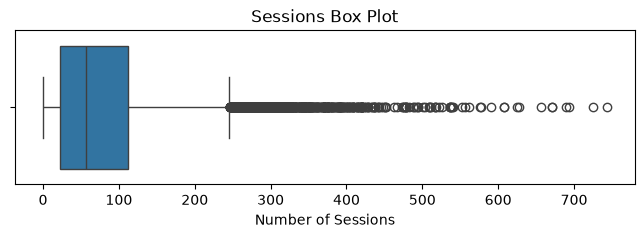

In [7]:
# Create a box plot to identify the distribution and outliers in sessions
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['sessions'])
plt.title('Sessions Box Plot')
plt.xlabel('Number of Sessions')
plt.show()

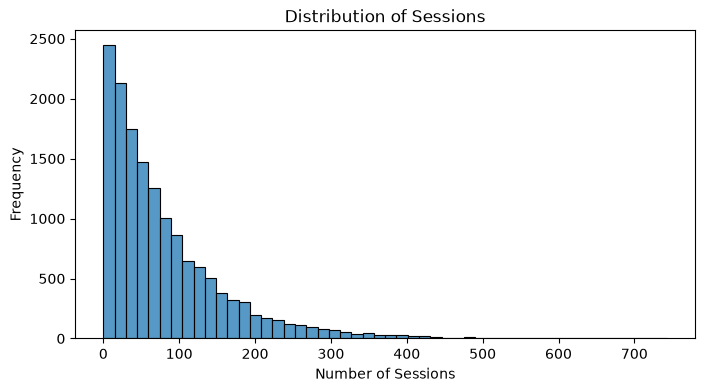

In [8]:
# Create a histogram to examine the distribution of sessions
plt.figure(figsize=(8, 4))
sns.histplot(df['sessions'], bins=50)
plt.title('Distribution of Sessions')
plt.xlabel('Number of Sessions')
plt.ylabel('Frequency')
plt.show()

The `sessions` variable is a right-skewed distribution with half of the observations having 56 or fewer sessions. However, as indicated by the boxplot, some users have more than 700.

### Drives


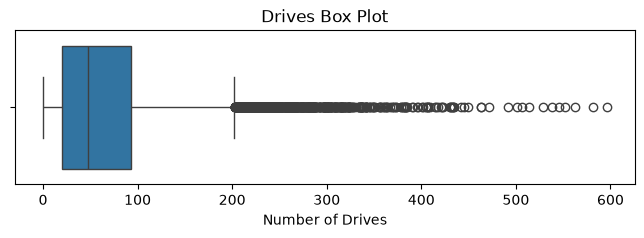

In [9]:
# Create a box plot to inspect the distribution of monthly drives
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['drives'])
plt.title('Drives Box Plot')
plt.xlabel('Number of Drives')
plt.show()

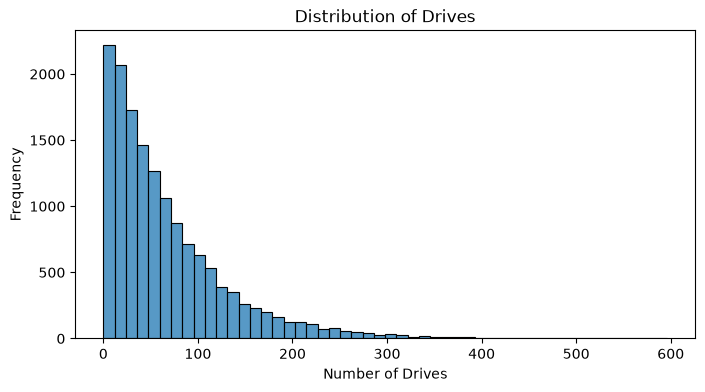

In [10]:
# Plot the distribution of the number of drives
plt.figure(figsize=(8, 4))
sns.histplot(df['drives'], bins=50)
plt.title('Distribution of Drives')
plt.xlabel('Number of Drives')
plt.ylabel('Frequency')
plt.show()


The `drives` information follows a distribution similar to the `sessions` variable. It is right-skewed, approximately log-normal, with a median of 48. However, some drivers had over 400 drives in the last month.

### Total Sessions


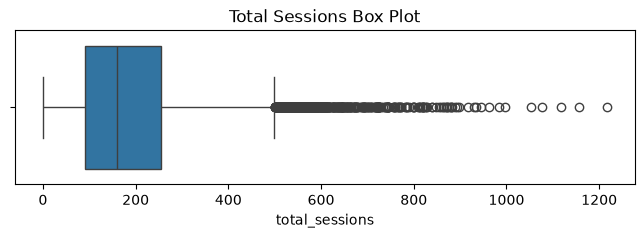

In [28]:
# Create a box plot of total sessions since onboarding
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['total_sessions'])
plt.title('Total Sessions Box Plot')
plt.show()

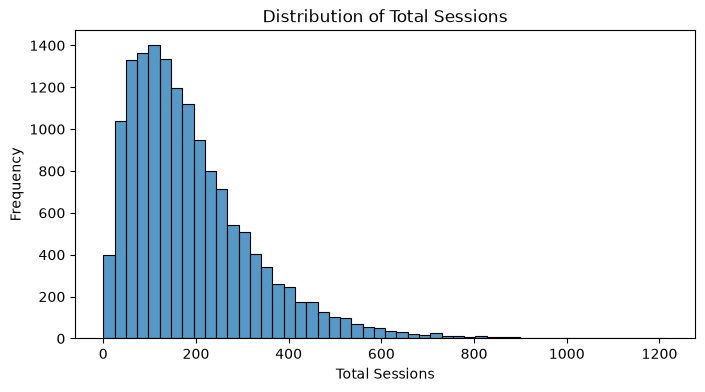

In [29]:
# Display the distribution of total sessions
plt.figure(figsize=(8, 4))
sns.histplot(df['total_sessions'], bins=50)
plt.title('Distribution of Total Sessions')
plt.xlabel('Total Sessions')
plt.ylabel('Frequency')
plt.show()

The `total_sessions` is a right-skewed distribution. The median total number of sessions is 159.6. This is interesting information because, if the median number of sessions in the last month was 48 and the median total sessions was ~160, then it seems that a large proportion of a user's total drives might have taken place in the last month. This is something you can examine more closely later.

### User Tenure


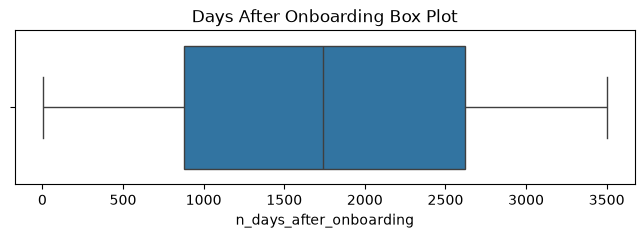

In [30]:
# Examine user tenure and identify possible extreme values
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['n_days_after_onboarding'])
plt.title('Days After Onboarding Box Plot')
plt.show()

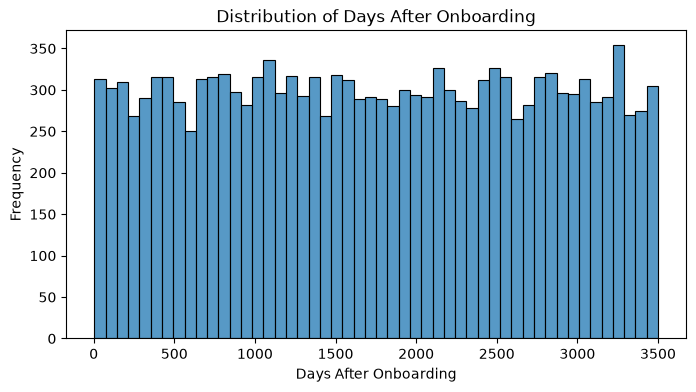

In [31]:
# Plot the distribution of the number of days since onboarding
plt.figure(figsize=(8, 4))
sns.histplot(df['n_days_after_onboarding'], bins=50)
plt.title('Distribution of Days After Onboarding')
plt.xlabel('Days After Onboarding')
plt.ylabel('Frequency')
plt.show()

The total user tenure (i.e., number of days since
onboarding) is a uniform distribution with values ranging from near-zero to \~3,500 (\~9.5 years).

### Distance Driven


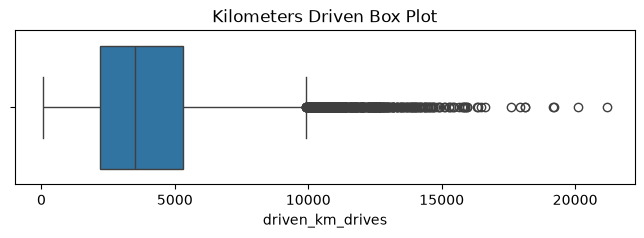

In [32]:
# Create a box plot of total kilometers driven during the month
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['driven_km_drives'])
plt.title('Kilometers Driven Box Plot')
plt.show()

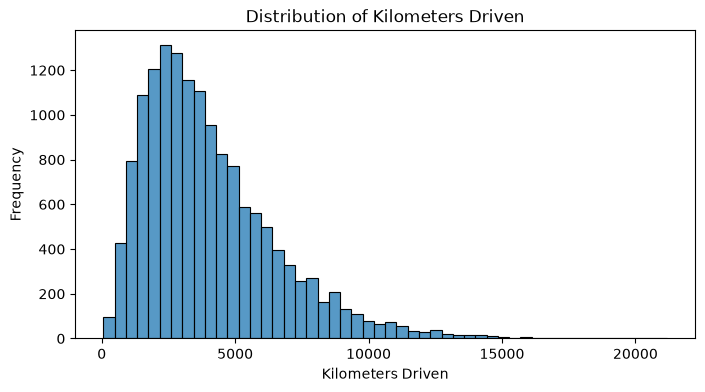

In [33]:
# Examine the distribution of monthly distance driven
plt.figure(figsize=(8, 4))
sns.histplot(df['driven_km_drives'], bins=50)
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Frequency')
plt.show()

The number of drives driven in the last month per user is a right-skewed distribution with half the users driving under 3,495 kilometers. As you discovered in the analysis from the previous course, the users in this dataset drive _a lot_. The longest distance driven in the month was over half the circumferene of the earth.

### Driving Duration


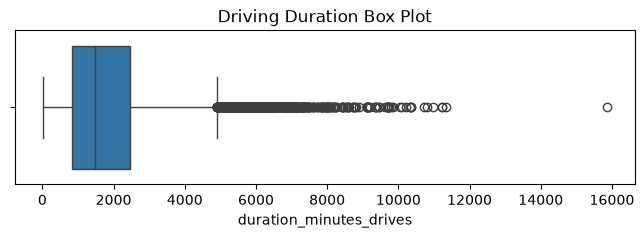

In [34]:
# Create a box plot of total driving duration
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['duration_minutes_drives'])
plt.title('Driving Duration Box Plot')
plt.show()

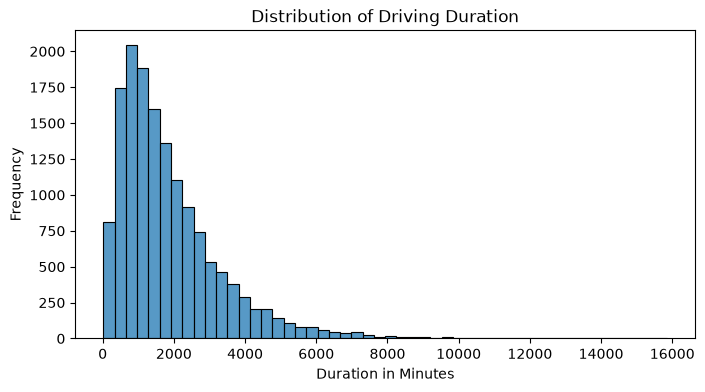

In [35]:
# Examine the distribution of total driving duration
plt.figure(figsize=(8, 4))
sns.histplot(df['duration_minutes_drives'], bins=50)
plt.title('Distribution of Driving Duration')
plt.xlabel('Duration in Minutes')
plt.ylabel('Frequency')
plt.show()

The `duration_minutes_drives` variable has a heavily skewed right tail. Half of the users drove less than \~1,478 minutes (\~25 hours), but some users clocked over 250 hours over the month.

### Activity Days


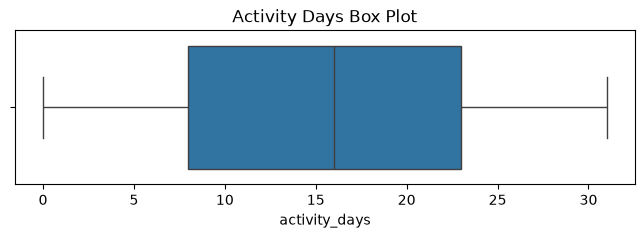

In [36]:
# Create a box plot of the number of days users opened Waze
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['activity_days'])
plt.title('Activity Days Box Plot')
plt.show()

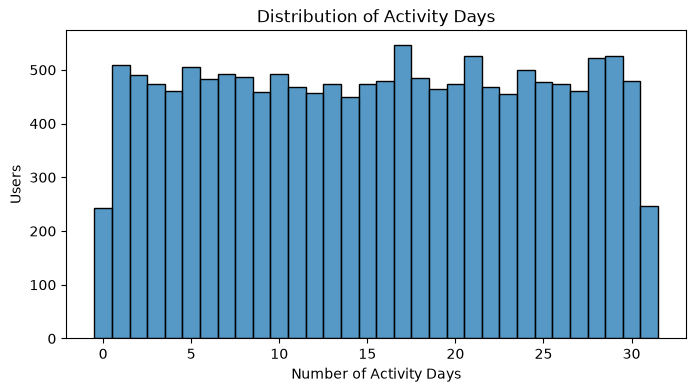

In [37]:
# Display the frequency of app activity days
plt.figure(figsize=(8, 4))
sns.histplot(df['activity_days'], bins=31, discrete=True)
plt.title('Distribution of Activity Days')
plt.xlabel('Number of Activity Days')
plt.ylabel('Users')
plt.show()

Within the last month, users opened the app a median of 16 times. The box plot reveals a centered distribution. The histogram shows a nearly uniform distribution of ~500 people opening the app on each count of days. However, there are ~250 people who didn't open the app at all and ~250 people who opened the app every day of the month.

This distribution is noteworthy because it does not mirror the `sessions` distribution, which you might think would be closely correlated with `activity_days`.

### Driving Days


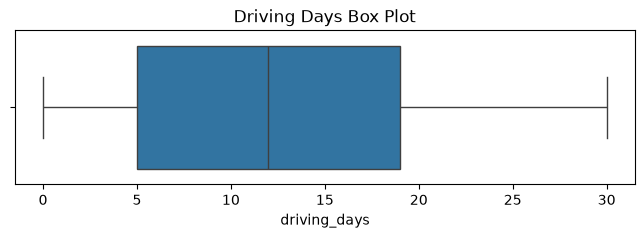

In [38]:
# Create a box plot showing monthly driving-day values
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['driving_days'])
plt.title('Driving Days Box Plot')
plt.show()

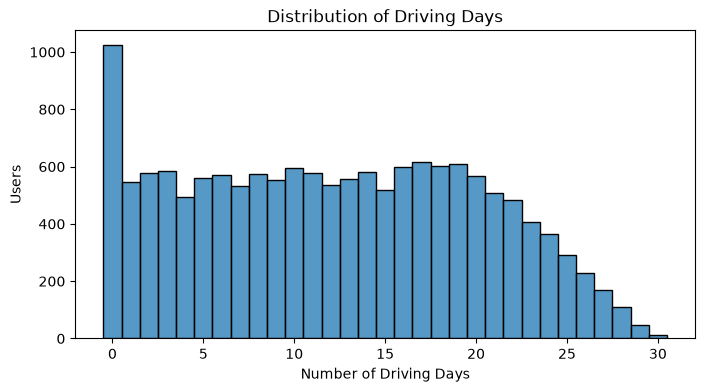

In [39]:
# Display the distribution of driving days
plt.figure(figsize=(8, 4))
sns.histplot(df['driving_days'], bins=31, discrete=True)
plt.title('Distribution of Driving Days')
plt.xlabel('Number of Driving Days')
plt.ylabel('Users')
plt.show()

The number of days users drove each month is almost uniform, and it largely correlates with the number of days they opened the app that month, except the `driving_days` distribution tails off on the right.

However, there were almost twice as many users (\~1,000 vs. \~550) who did not drive at all during the month. This might seem counterintuitive when considered together with the information from `activity_days`. That variable had \~500 users opening the app on each of most of the day counts, but there were only \~250 users who did not open the app at all during the month and ~250 users who opened the app every day. Flag this for further investigation later.

### Device Distribution


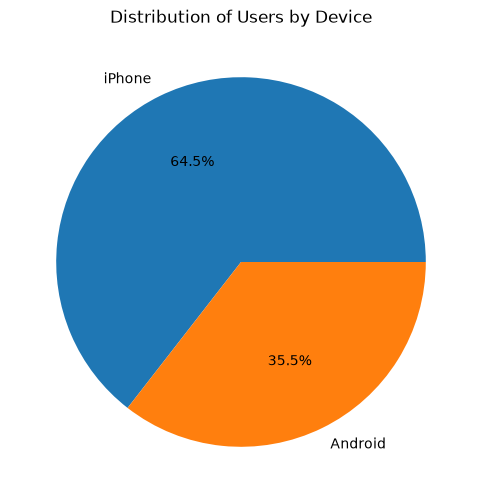

In [40]:
# Count the number of users for each device type
device_counts = df['device'].value_counts()

# Plot the proportion of iPhone and Android users
plt.figure(figsize=(6, 6))
plt.pie(
    device_counts,
    labels=device_counts.index,
    autopct='%1.1f%%'
)
plt.title('Distribution of Users by Device')
plt.show()

There are nearly twice as many iPhone users as Android users represented in this data.

### Churn Distribution


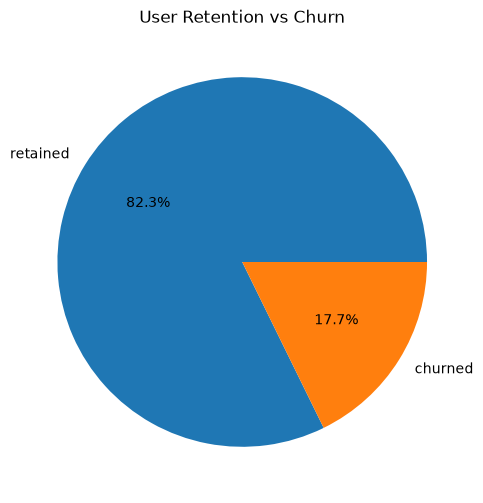

In [41]:
# Count retained and churned users
label_counts = df['label'].value_counts()

# Plot the proportion of retained and churned users
plt.figure(figsize=(6, 6))
plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%'
)
plt.title('User Retention vs Churn')
plt.show()

Less than 18% of the users churned.

## 3. Behavioural Relationships and Churn Analysis


### Activity Days vs. Driving Days


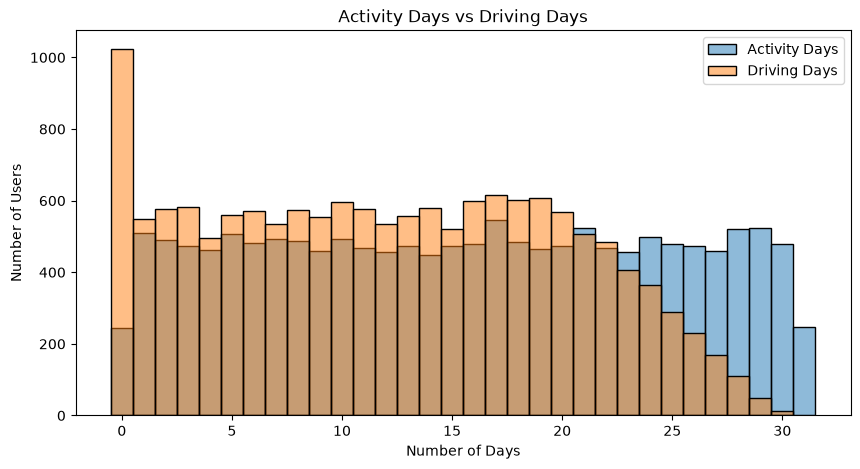

In [42]:
# Plot activity days and driving days on the same chart for comparison
plt.figure(figsize=(10, 5))

sns.histplot(
    df['activity_days'],
    bins=31,
    discrete=True,
    alpha=0.5,
    label='Activity Days'
)

sns.histplot(
    df['driving_days'],
    bins=31,
    discrete=True,
    alpha=0.5,
    label='Driving Days'
)

plt.title('Activity Days vs Driving Days')
plt.xlabel('Number of Days')
plt.ylabel('Number of Users')
plt.legend()
plt.show()

In [43]:
# Check the maximum values for driving and activity days
print('Maximum driving days:', df['driving_days'].max())
print('Maximum activity days:', df['activity_days'].max())

Maximum driving days: 30
Maximum activity days: 31


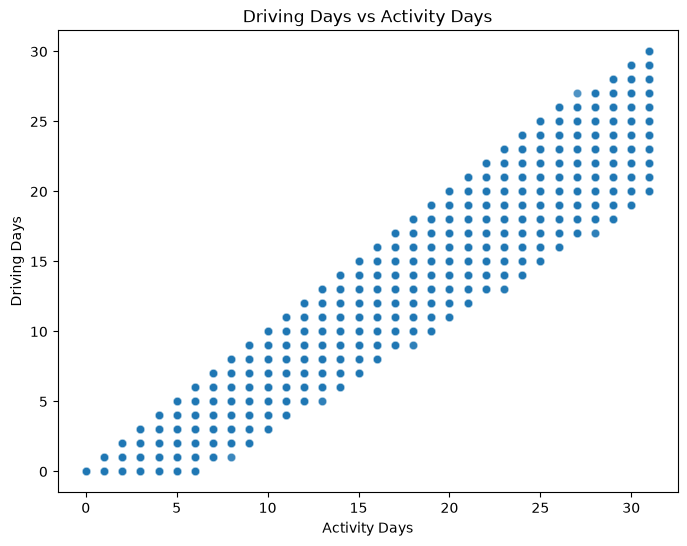

In [44]:
# Examine the relationship between activity days and driving days
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='activity_days',
    y='driving_days',
    alpha=0.4
)

plt.title('Driving Days vs Activity Days')
plt.xlabel('Activity Days')
plt.ylabel('Driving Days')
plt.show()

Notice that there is a theoretical limit. If you use the app to drive, then by definition it must count as a day-use as well. In other words, you cannot have more drive-days than activity-days. None of the samples in this data violate this rule, which is good.

### Retention by Device


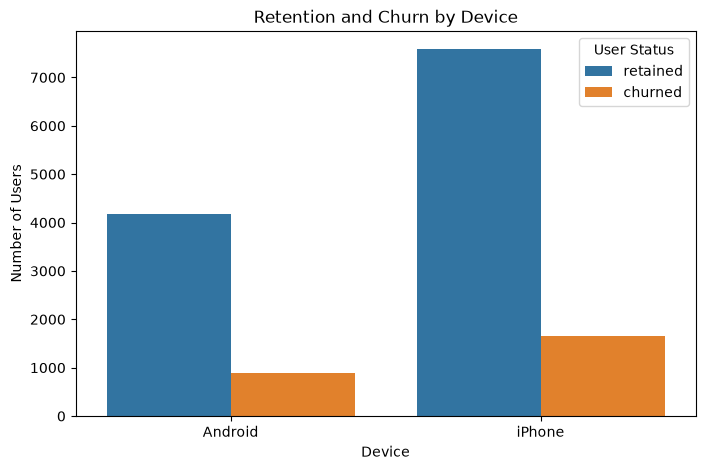

In [45]:
# Compare churn and retention counts for each device type
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='device',
    hue='label'
)

plt.title('Retention and Churn by Device')
plt.xlabel('Device')
plt.ylabel('Number of Users')
plt.legend(title='User Status')
plt.show()

The proportion of churned users to retained users is consistent between device types.

### Kilometres Driven per Driving Day
A derived feature is created to examine average distance driven on active driving days. Infinite values caused by division by zero are handled before interpretation.


In [46]:
# Calculate the average kilometers driven per driving day
df['km_per_driving_day'] = (
    df['driven_km_drives'] / df['driving_days']
)

# Display summary statistics for the new calculated variable
df['km_per_driving_day'].describe()

C:\Users\Francis\anaconda3\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [47]:
# Replace infinite values caused by division by zero with zero
df['km_per_driving_day'] = (
    df['km_per_driving_day'].replace([np.inf, -np.inf], 0)
)

In [48]:
# Verify that infinite values were successfully removed
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

The churn rate tends to increase as the mean daily distance driven increases, confirming what was found in the previous course. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

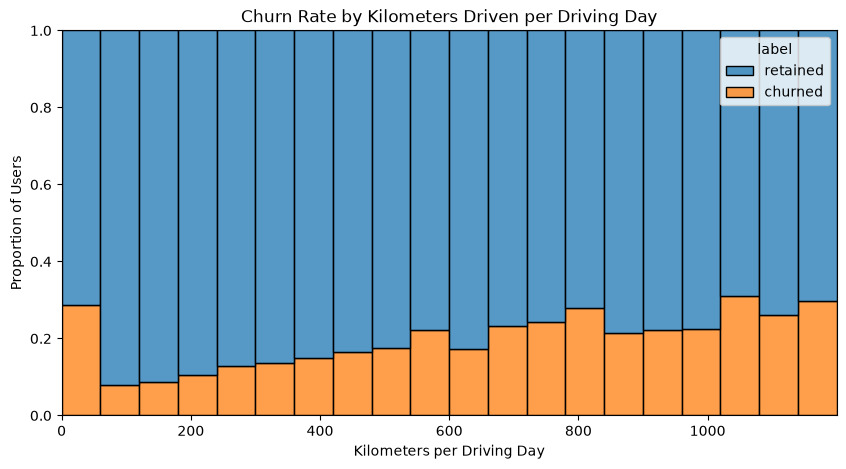

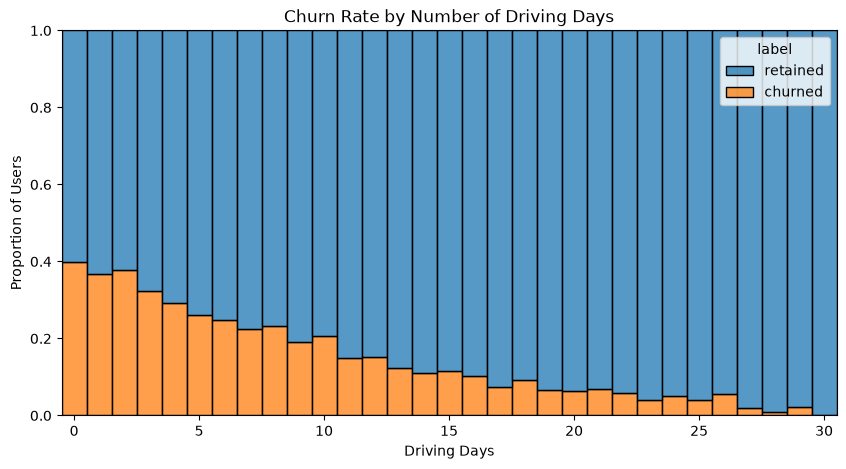

In [49]:
# Keep realistic values of 1,200 km per driving day or less
plot_df = df[df['km_per_driving_day'] <= 1200]

# Compare churn proportions across distance groups
plt.figure(figsize=(10, 5))

sns.histplot(
    data=plot_df,
    x='km_per_driving_day',
    hue='label',
    multiple='fill',
    bins=20
)

plt.title('Churn Rate by Kilometers Driven per Driving Day')
plt.xlabel('Kilometers per Driving Day')
plt.ylabel('Proportion of Users')
plt.show()


# Compare churn proportions across the number of driving days
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='driving_days',
    hue='label',
    multiple='fill',
    discrete=True
)

plt.title('Churn Rate by Number of Driving Days')
plt.xlabel('Driving Days')
plt.ylabel('Proportion of Users')
plt.show()

The churn rate is highest for people who didn't use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn't use the app at all last month churned, nobody who used the app 30 days churned.

This isn't surprising. If people who used the app a lot churned, it would likely indicate dissatisfaction. When people who don't use the app churn, it might be the result of dissatisfaction in the past, or it might be indicative of a lesser need for a navigational app. Maybe they moved to a city with good public transportation and don't need to drive anymore.

### Recent Session Activity
The proportion of each user’s total sessions that occurred in the most recent month is calculated to investigate recent engagement relative to historical usage.


In [50]:
# Calculate the percentage of total sessions that occurred in the last month
df['percent_sessions_in_last_month'] = (
    df['sessions'] / df['total_sessions']
)

In [51]:
# Calculate the median proportion of sessions occurring in the last month
df['percent_sessions_in_last_month'].median()

np.float64(0.42309702992763176)

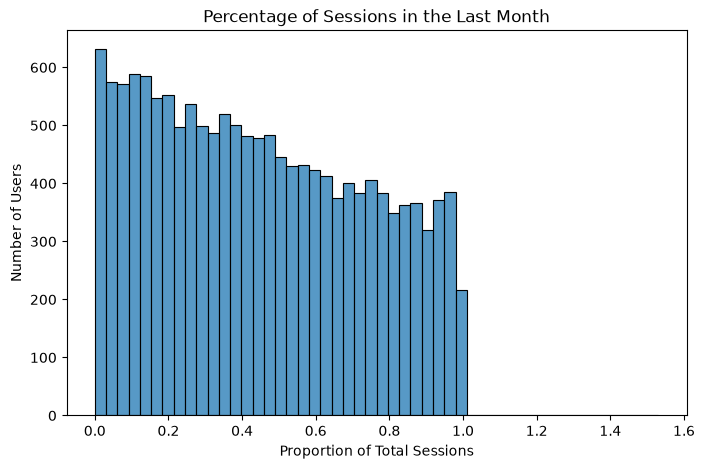

In [52]:
# Plot the distribution of the proportion of recent sessions
plt.figure(figsize=(8, 5))

sns.histplot(
    df['percent_sessions_in_last_month'],
    bins=50
)

plt.title('Percentage of Sessions in the Last Month')
plt.xlabel('Proportion of Total Sessions')
plt.ylabel('Number of Users')
plt.show()

In [53]:
# Calculate the median number of days since users onboarded
df['n_days_after_onboarding'].median()

np.float64(1741.0)

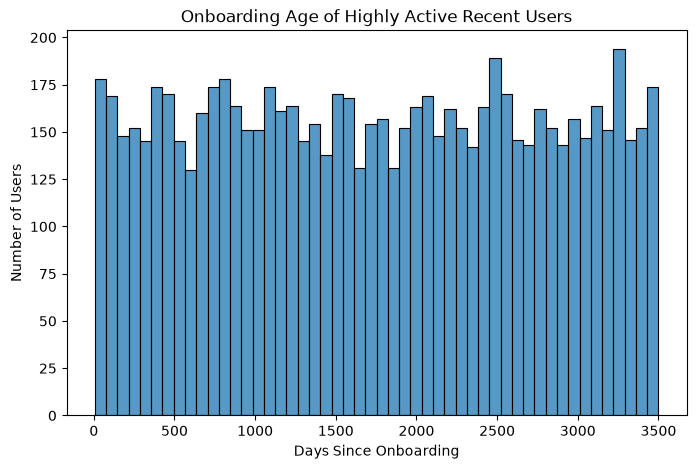

In [54]:
# Select users who completed at least 40% of their sessions in the last month
high_recent_activity = df[
    df['percent_sessions_in_last_month'] >= 0.40
]

# Plot their number of days since onboarding
plt.figure(figsize=(8, 5))

sns.histplot(
    high_recent_activity['n_days_after_onboarding'],
    bins=50
)

plt.title('Onboarding Age of Highly Active Recent Users')
plt.xlabel('Days Since Onboarding')
plt.ylabel('Number of Users')
plt.show()

The number of days since onboarding for users with 40% or more of their total sessions occurring in just the last month is a uniform distribution. This is very strange. It's worth asking Waze why so many long-time users suddenly used the app so much in the last month.

## 4. Outlier Handling
Several numerical variables contain legitimate extreme observations. A reusable function caps selected variables at their 95th percentile to reduce the influence of extreme values without discarding user records.


In [55]:
# Define a function that caps extreme values at the 95th percentile
def cap_outliers(df, column_name):
    
    # Calculate the 95th percentile for the selected column
    threshold = df[column_name].quantile(0.95)
    
    # Replace values above the threshold with the threshold value
    df.loc[df[column_name] > threshold, column_name] = threshold

In [56]:
# List the numerical columns whose extreme values will be capped
columns_to_cap = [
    'sessions',
    'drives',
    'total_sessions',
    'driven_km_drives',
    'duration_minutes_drives'
]

# Apply the outlier-capping function to each selected column
for column in columns_to_cap:
    cap_outliers(df, column)

In [57]:
# Review the updated descriptive statistics after handling outliers
df[columns_to_cap].describe()

,sessions,drives,total_sessions,driven_km_drives,duration_minutes_drives
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,76.568705,64.058204,184.031320,3939.632764,1789.647426
std,67.297958,55.306924,118.600463,2216.041510,1222.705167
min,0.000000,0.000000,0.220211,60.441250,18.282082
25%,23.000000,20.000000,90.661156,2212.600607,835.996260
50%,56.000000,48.000000,159.568115,3493.858085,1478.249859
75%,112.000000,93.000000,254.192341,5289.861262,2464.362632
max,243.000000,201.000000,454.363204,8889.794236,4668.899349


## 5. Additional Churn Comparison


In [58]:
# Compare median user behavior between retained and churned users
df.groupby('label')[
    ['sessions', 'drives', 'driving_days', 'activity_days']
].median()


,sessions,drives,driving_days,activity_days
label,,,,
churned,59.0,50.0,6.0,8.0
retained,56.0,47.0,14.0,17.0


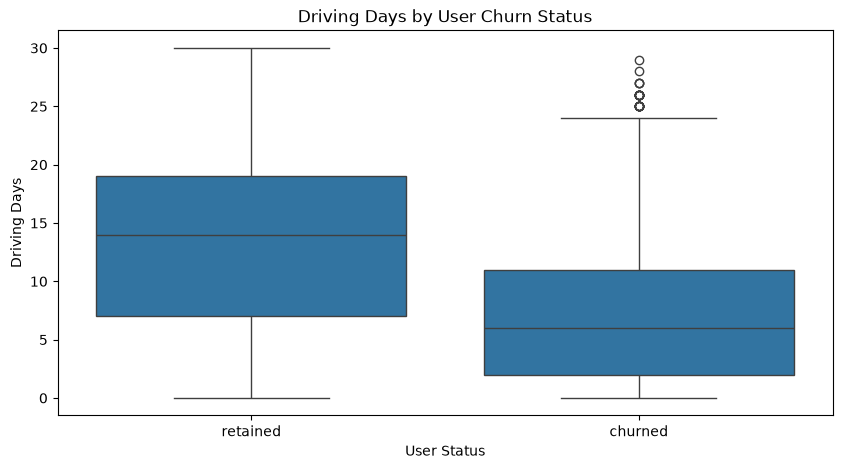

In [59]:
# Visualize the relationship between driving frequency and churn
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='label',
    y='driving_days'
)

plt.title('Driving Days by User Churn Status')
plt.xlabel('User Status')
plt.ylabel('Driving Days')
plt.show()

# Compare driving frequency between retained and churned users


## 6. Key Findings
- The overall churn rate is approximately **17%**.
- Churn proportions are broadly consistent between iPhone and Android users, suggesting device type alone is unlikely to explain churn.
- Several behavioural variables—including sessions, drives, kilometres driven, and driving duration—are strongly right-skewed and contain high-value observations.
- Activity days and driving days show more even distributions and are closely related measures of user engagement.
- Churn is higher among users with lower recent Waze usage; users who engage with the app more frequently tend to show lower churn.
- Distance-per-driving-day analysis reveals implausibly large values for some observations, highlighting the importance of validation and careful outlier treatment.
- Some recent-session patterns appear unusual relative to user tenure and merit further investigation before predictive modelling.


## 7. Business Recommendations
1. **Prioritise engagement signals in churn analysis.** Driving days, activity days, sessions, and drives provide useful behavioural indicators for distinguishing user engagement levels.
2. **Avoid device-specific retention decisions based on this analysis alone.** Churn proportions are similar across iPhone and Android users.
3. **Investigate low-activity users more closely.** Higher churn among infrequent users suggests that declining engagement may be an important retention signal.
4. **Validate extreme behavioural values before modelling.** Very high distance and duration values should be checked for data-quality issues or unusual usage patterns.
5. **Use these EDA findings to guide predictive modelling.** The identified behavioural relationships can inform feature selection and subsequent churn models.


## 8. Limitations and Next Steps
This exploratory analysis identifies associations rather than causal relationships. Some variables contain extreme or unusual values that require validation. The next stage should include formal statistical testing and predictive modelling to determine which behavioural features provide reliable explanatory or predictive value for churn.


## 9. Conclusion
The exploratory analysis shows that Waze churn is more closely associated with patterns of user activity and driving behaviour than with device type. The findings provide a structured basis for deeper statistical analysis and future churn-prediction modelling.
